In [128]:
import stock_data
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [129]:
def simulate_portfolio(prices, signals, initial_balance=10000):
    """
    Simulates portfolio balance over time based on buy/sell signals.

    Parameters:
        prices (pd.Series): Series of actual prices (e.g., closing price).
        signals (list or Series): List of 'buy' or 'sell' signals (must align with prices).
        initial_balance (float): Starting portfolio value.

    Returns:
        pd.DataFrame: Portfolio balance, holdings, and action log over time.
    """
    df = pd.DataFrame({
        "price": prices.values,
        "signal": signals
    }).reset_index(drop=True)

    balance = initial_balance
    holdings = 0
    portfolio_values = []

    for i in range(len(df) - 1):  # use next day's price
        today_signal = df.loc[i, "signal"]
        next_price = df.loc[i + 1, "price"]

        if today_signal == "buy" and holdings == 0:
            # Buy with full balance
            holdings = balance / next_price
            assert(not np.isnan(holdings))
            balance = 0
            action = "BUY"
        elif today_signal == "sell" and holdings > 0:
            # Sell all holdings
            balance = holdings * next_price
            holdings = 0
            action = "SELL"
        else:
            action = "HOLD"

        portfolio_value = balance + holdings * next_price
        portfolio_values.append({
            "day": i,
            "price": next_price,
            "signal": today_signal,
            "action": action,
            "holdings": holdings,
            "balance": balance,
            "portfolio_value": portfolio_value
        })

    return pd.DataFrame(portfolio_values)

def classify_signal_with_hold(probs, threshold=0.6):
    """
    Converts class probabilities into 'buy', 'sell', or 'hold' signals.
    - probs: Nx2 numpy array from model.predict_proba(X)
    - threshold: minimum probability to trigger a buy/sell
    """
    signals = []

    for prob_down, prob_up in probs:
        if prob_up >= threshold:
            signals.append("buy")
        elif prob_down >= threshold:
            signals.append("sell")
        else:
            signals.append("hold")

    return signals

def compute_sharpe_ratio(portfolio_df, risk_free_rate=0.0, period_per_year=52):
    """
    Compute annualized Sharpe Ratio from a portfolio value series.

    Parameters:
        portfolio_df: DataFrame with 'portfolio_value' column
        risk_free_rate: annual risk-free rate (default 0)
        period_per_year: number of periods per year (e.g., 52 for weekly)

    Returns:
        Sharpe ratio (float)
    """
    # Compute periodic returns (e.g., weekly)
    returns = portfolio_df["portfolio_value"].pct_change().dropna()

    # Mean and std of returns
    mean_return = returns.mean()
    std_return = returns.std()

    # Annualize
    excess_return = mean_return - (risk_free_rate / period_per_year)
    sharpe_ratio = (excess_return / std_return) * np.sqrt(period_per_year)

    return sharpe_ratio

In [130]:
tickers = [
    # The classics
    "SPY", "VTV", "VTG", "QQQ", "SCHD",

    # Blue-chip stocks
    "JNJ", "PG", "KO", "PEP", "WMT", "MCD",
    
    # Low-volatility ETFs
    "USMV", "SPLV", "VIG", "SCHD", "VTV",
    
    # Defensive sector ETFs
    "XLU", "XLV", "XLP",

    "DGRW", "VYM", "HDV", "NOBL", "DGRO", "FDL", "DVY", "SPHD", #"VPU", "FSTA", "FUTY", "IDU", "RHS", "VDC", "IYK", "PFXF", "PFFD", "PSK", "LDRS", "LVHD", "QDF", "FTSD", "TLO", "SPLB", "SPBO", "BND", "AGG", "SHY", "TIP"
]


df = pd.DataFrame()
for ticker in tickers:
    sub_df = stock_data.get_normalized_data(ticker)
    sub_df["ticker"] = ticker
    df = pd.concat([df, sub_df], axis=0)

In [131]:
# Set target
# df["Target"] = df['price'].shift(-1) # regression
df = df.dropna()
df['Target'] = (df['price'].shift(-1) > df['price']).astype(int) # classification

In [132]:
X = df.copy()
X = X.drop(labels=["Target", "ticker"], axis=1)
X["date"] = pd.to_datetime(X["date"]).astype('int64')

y = df["Target"].copy()

split_index = int(len(df) * 0.8)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [133]:
# model = RandomForestClassifier(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))
# print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [135]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error

# Scale features (PyTorch models need this)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Define neural network model
# class BinaryClassifier(nn.Module):
#     def __init__(self, input_dim):
#         super(BinaryClassifier, self).__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_dim, 64),
#             nn.ReLU(),
#             # nn.Dropout(0.3),
#             nn.Linear(64, 128),
#             nn.ReLU(),
#             nn.Linear(128, 128),
#             nn.ReLU(),
#             nn.Linear(128, 64),
#             nn.ReLU(),
#             nn.Linear(64, 64),
#             nn.ReLU(),
#             nn.Linear(64, 32),
#             nn.ReLU(),
#             nn.Dropout(0.2),
#             nn.Linear(32, 1),
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         return self.net(x)

class BinaryClassifier(nn.Module):
    def __init__(self, input_dim):
        super(BinaryClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Instantiate model, loss, optimizer
model = BinaryClassifier(input_dim=X_train_tensor.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)

# Train loop
epochs = int(1200)
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss.item():.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    y_prob = model(X_test_tensor).squeeze()
    y_pred = (y_prob >= 0.5).int()

# Convert to NumPy for evaluation
y_prob_np = y_prob.numpy()
y_pred_np = y_pred.numpy()
y_test_np = y_test_tensor.squeeze().numpy()

# Metrics
print("Accuracy:", accuracy_score(y_test_np, y_pred_np))
print("\nClassification Report:\n", classification_report(y_test_np, y_pred_np))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_np, y_pred_np))

Epoch [100/1200] Loss: 0.6782
Epoch [200/1200] Loss: 0.6705
Epoch [300/1200] Loss: 0.6640
Epoch [400/1200] Loss: 0.6561
Epoch [500/1200] Loss: 0.6513
Epoch [600/1200] Loss: 0.6459
Epoch [700/1200] Loss: 0.6425
Epoch [800/1200] Loss: 0.6399
Epoch [900/1200] Loss: 0.6386
Epoch [1000/1200] Loss: 0.6368
Epoch [1100/1200] Loss: 0.6355
Epoch [1200/1200] Loss: 0.6323
Accuracy: 0.6346265199768385

Classification Report:
               precision    recall  f1-score   support

         0.0       0.59      0.43      0.50      2192
         1.0       0.65      0.78      0.71      2989

    accuracy                           0.63      5181
   macro avg       0.62      0.61      0.61      5181
weighted avg       0.63      0.63      0.62      5181


Confusion Matrix:
 [[ 943 1249]
 [ 644 2345]]


In [150]:
SIM_TICKER = "SPY"

sim_X = stock_data.get_normalized_data(SIM_TICKER)
sim_prices = stock_data.get_stock_data(SIM_TICKER)["price"].iloc[sim_X.index]
sim_X["date"] = pd.to_datetime(sim_X["date"]).astype('int64')

# For RandomForest:
# signals = classify_signal_with_hold(???, 0.95)
# For NN:
sim_X_tensor = torch.tensor(scaler.transform(sim_X), dtype=torch.float32)
model.eval()
with torch.no_grad():
    y_prob = model(sim_X_tensor).squeeze()
    y_pred = (y_prob >= 0.5).int()
probabilities = pd.DataFrame({"prob": y_prob.numpy()})
probabilities["class"] = "hold"
probabilities.loc[probabilities["prob"] > 0.8,"class"] = "buy"
probabilities.loc[probabilities["prob"] < 0.2,"class"] = "sell"
probabilities
signals = probabilities["class"]
portfolio_df = simulate_portfolio(prices=sim_prices, signals=signals)
portfolio_df[portfolio_df["action"] != "HOLD"]

,day,price,signal,action,holdings,balance,portfolio_value
435,435,95.7928,buy,BUY,104.391979,0.000000,10000.000000
466,466,63.8012,sell,SELL,0.000000,6660.333553,6660.333553
486,486,56.2297,buy,BUY,118.448677,0.000000,6660.333553
624,624,98.1509,sell,SELL,0.000000,11625.844217,11625.844217
625,625,99.0739,buy,BUY,117.345176,0.000000,11625.844217
638,638,105.7625,sell,SELL,0.000000,12410.719160,12410.719160
639,639,107.3762,buy,BUY,115.581657,0.000000,12410.719160
843,843,160.4483,sell,SELL,0.000000,18544.880439,18544.880439
844,844,162.7635,buy,BUY,113.937587,0.000000,18544.880439
951,951,232.6338,sell,SELL,0.000000,26505.733823,26505.733823


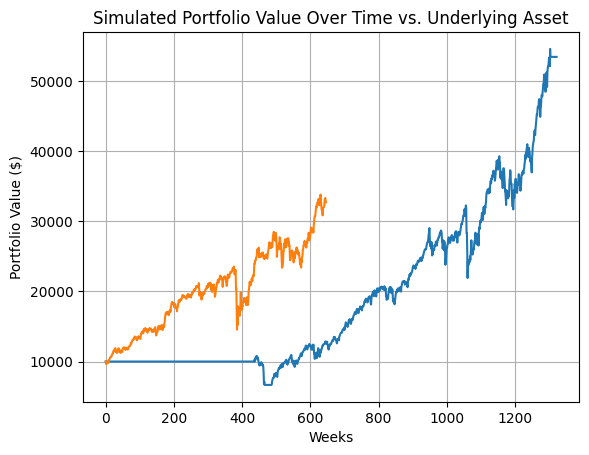

Final Portfolio Value: $53491.36
Sharpe Ratio: 0.4482


In [151]:
import matplotlib.pyplot as plt
plt.plot(portfolio_df["portfolio_value"])
def plot_buy_and_hold(ticker):
    sim_prices = stock_data.get_stock_data(ticker)["price"]
    plt.plot((sim_prices/sim_prices[0]) * portfolio_df["portfolio_value"][0])

# plot_buy_and_hold("SPY")
# plot_buy_and_hold("QQQ")
plot_buy_and_hold("SPHD")

plt.plot(())
plt.title("Simulated Portfolio Value Over Time vs. Underlying Asset")
plt.xlabel("Weeks")
plt.ylabel("Portfolio Value ($)")
plt.grid(True)
plt.show()

# Optional: print final value
print(f"Final Portfolio Value: ${portfolio_df['portfolio_value'].iloc[-1]:.2f}")
sharpe = compute_sharpe_ratio(portfolio_df, risk_free_rate=0.015, period_per_year=52)
print(f"Sharpe Ratio: {sharpe:.4f}")
